# Multi-Task v4 + Tier-A Preprocessing

Single-variable ablation on top of [[MultiTaskEncoderUNetV4]]. Replaces the bare `/255` normalization with the standard X-ray preprocessing stack missing from our pipeline per [[Preprocessing_options]] §"Tier A — missing fundamentals".

**What changes vs v4 (preprocessing only):**
1. **Percentile windowing** — clip pixel intensities to `[0.5, 99.5]` percentile per image, then rescale to `[0, 255]` uint8
2. **Real CLAHE** — `cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))` (replaces the fake `clahe_like` Gaussian-blur trick used as augmentation only)
3. **Per-image z-score** — `(x - μ_img) / σ_img` applied AFTER augmentation, replaces the `/255` rescale

**What stays identical to v4:**
- Architecture (`MultiTaskEncoderUNet`, ResNet-34 encoder, `in_ch=1`)
- Loss (`MixedLoss` = clamped Kendall on `(seg, cobb)` + fixed `λ_kpt=1.0`)
- Augmentation chain (`augment_v5_cobb_aware`) — applied on `[0, 1]` post-CLAHE image, before z-score
- Training schedule (150 ep, patience 25, encoder freeze warmup 10 ep, dual-checkpoint)
- Single 80/20 split, same seed → directly comparable to v4 leaderboard row

**Acceptance gate (vs v4 baseline):**
- best dice ≥ 0.680 (no regression from v4) — Tier-A is hygiene, must not hurt seg
- best cobb_direct MAE ≤ 5.79° → preprocessing was the gap; promote to Q-18 stack
- 5.79° < cobb < 6.69° → modest help, still proceed to Q-18
- cobb > 6.69° → preprocessing not the gap; ablate which of (window/CLAHE/z-score) hurt

**Decision tree post-run** is filed in [[hot.md]] §Active Threads. If this run lifts the floor, Q-18 corner-chaining stacks on top before Q-01 5-fold CV.

Cache key: `ai/models/checkpoints/multitask_v4_tierA/<timestamp>_<hash>/` — isolated from v4 cache via the `preprocessing: "tierA_window_clahe_zscore"` field in `run_config()`.


## 0 · Setup


In [2]:
import math
import sys
import time
import warnings
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from torch.utils.data import DataLoader, Dataset
from torchvision import models

warnings.filterwarnings("ignore", message=".*lerp.*")


In [3]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "params.yaml").exists():
            return p
    raise FileNotFoundError("params.yaml not found above CWD")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PARAMS = yaml.safe_load((REPO_ROOT / "params.yaml").read_text())
SEED = int(PARAMS["data"]["random_seed"])

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    try:
        import torch_directml
        DEVICE = torch_directml.device()
    except ImportError:
        DEVICE = torch.device("cpu")
print(f"repo={REPO_ROOT}\ndevice={DEVICE}\nseed={SEED}")

repo=/home/ortiz/scoliosis
device=privateuseone:0
seed=42


In [4]:
from ai.evaluation.cobb import cobb_from_segmentation_tangent
from ai.preprocessing.keypoints import (
    KEYPOINTS_PER_VERTEBRA,
    TOTAL_KEYPOINTS,
    multiclass_mask_to_keypoints,
)
from ai.preprocessing.segmentation import NUM_SEG_CLASSES
from ai.training.augmentation import (
    affine_transform,
    clahe_like,
    coarse_dropout,
    elastic_deform,
    gamma_correction,
    gaussian_blur,
    gaussian_noise,
    horizontal_flip,
    intensity_jitter,
)
from ai.training.dataset import (
    IMG_H,
    IMG_W,
    TARGET_IDS_V2,
    preprocess_case,
)
from ai.training.losses import seg_loss_fn

NUM_VERT = len(TARGET_IDS_V2)
print(f"size={IMG_H}x{IMG_W}  seg_classes={NUM_SEG_CLASSES}  vertebrae={NUM_VERT}  keypoints={TOTAL_KEYPOINTS}")


size=512x256  seg_classes=18  vertebrae=17  keypoints=68


In [5]:
CLEAN_INDEX_CSV = REPO_ROOT / "data" / "processed" / "audit_v2_corrected" / "clean_index.csv"

def load_clean_index(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"{path} missing — run audit generation first")
    return pd.read_csv(path)

def trainable_rows(df: pd.DataFrame, min_vertebrae: int = 14) -> pd.DataFrame:
    mask = df["status"].isin(["ok", "warn"])
    if "target_vertebrae_count" in df.columns:
        mask = mask & (df["target_vertebrae_count"] >= min_vertebrae)
    return df[mask].reset_index(drop=True)

def split_train_val(df: pd.DataFrame, val_frac: float = 0.2, seed: int = SEED) -> tuple[pd.DataFrame, pd.DataFrame]:
    shuffled = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n_val = max(1, int(round(len(shuffled) * val_frac)))
    return shuffled.iloc[n_val:].reset_index(drop=True), shuffled.iloc[:n_val].reset_index(drop=True)

CLEAN_INDEX = load_clean_index(CLEAN_INDEX_CSV)
TRAINABLE = trainable_rows(CLEAN_INDEX)
TRAIN_DF, VAL_DF = split_train_val(TRAINABLE, val_frac=0.2, seed=SEED)
n_with_cobb = TRAINABLE["cobb_angle_deg"].notna().sum()
print(f"total={len(CLEAN_INDEX)}  trainable={len(TRAINABLE)} (cobb_gt={n_with_cobb})  train={len(TRAIN_DF)}  val={len(VAL_DF)}")

total=250  trainable=249 (cobb_gt=178)  train=199  val=50


## 1 · I/O Contract — Three Targets per Sample (Tier-A inputs)

Same target shapes as v4. Only the **image** distribution changes:

| Tensor | Shape | Dtype | Source | Notes |
|---|---|---|---|---|
| `image` | `(1, 512, 256)` | float32 | grayscale X-ray, **percentile-windowed → CLAHE → z-scored** per image | mean ≈ 0, std ≈ 1, range ~`[-3, 3]` (NOT `[0, 1]` like v4) |
| `seg` | `(512, 256)` | int64 | per-pixel class `0..17` | unchanged |
| `kpt_heatmap` | `(68, 128, 64)` | float32 | Gaussian blob per corner at H/4 × W/4 | unchanged |
| `kpt_valid` | `(68,)` | bool | mask of finite keypoints | unchanged |
| `cobb` | `()` | float32 | scalar Cobb angle (degrees) | unchanged |
| `cobb_valid` | `()` | bool | True if `cobb` is finite | unchanged |


In [6]:
HEATMAP_DOWNSAMPLE = 4
HM_H = IMG_H // HEATMAP_DOWNSAMPLE  # 128
HM_W = IMG_W // HEATMAP_DOWNSAMPLE  # 64
HEATMAP_SIGMA = 2.0  # gaussian sigma in heatmap-resolution pixels

def render_heatmaps(
    keypoints_xy_full: np.ndarray,
    h: int = HM_H,
    w: int = HM_W,
    downsample: int = HEATMAP_DOWNSAMPLE,
    sigma: float = HEATMAP_SIGMA,
) -> tuple[np.ndarray, np.ndarray]:
    """Return (heatmaps (K,h,w) float32, valid (K,) bool)."""
    k = keypoints_xy_full.shape[0]
    hm = np.zeros((k, h, w), dtype=np.float32)
    valid = np.zeros((k,), dtype=bool)
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
    for i in range(k):
        x_full, y_full = keypoints_xy_full[i]
        if not (np.isfinite(x_full) and np.isfinite(y_full)):
            continue
        cx = x_full / downsample
        cy = y_full / downsample
        hm[i] = np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2.0 * sigma ** 2))
        valid[i] = True
    return hm, valid


def keypoints_from_heatmaps(
    hm: torch.Tensor,
    threshold: float = 0.1,
    upsample: int = HEATMAP_DOWNSAMPLE,
) -> tuple[np.ndarray, np.ndarray]:
    """Argmax peak per channel, scale to full-resolution pixel coords.

    Args:
        hm: (K, h, w) heatmap tensor
    Returns:
        coords: (K, 2) float array of (x, y) in full-resolution pixels (NaN if peak < threshold)
        scores: (K,) peak intensities
    """
    k, h, w = hm.shape
    flat = hm.reshape(k, -1)
    scores, idx = flat.max(dim=1)
    ys = (idx // w).float() * upsample
    xs = (idx % w).float() * upsample
    coords = torch.stack([xs, ys], dim=1).cpu().numpy()
    s = scores.cpu().numpy()
    coords[s < threshold] = np.nan
    return coords, s

## 1.5 · Tier-A Preprocessing Override

Local override of `preprocess_case` from `ai/training/dataset.py`. We do **not** modify the package function (other notebooks read v4-baseline `/255`); the override is notebook-scoped.

**Pipeline order matters**:
1. Read uint8 grayscale + resize (BILINEAR image, NEAREST mask) — same as v4
2. **Percentile windowing**: `np.percentile(img, [0.5, 99.5])` → clip → rescale clipped range to full `[0, 255]` uint8
3. **Real CLAHE**: `cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))` on the windowed uint8 image
4. `/255` → float32 in `[0, 1]`
5. *(at training only)* Augmentation chain on `[0, 1]` image — chain unchanged from v4
6. **Per-image z-score**: `(img - img.mean()) / (img.std() + 1e-6)` applied AFTER step 5

Steps 1–4 happen here in `preprocess_case_tierA`. Step 5 is `augment_v5_cobb_aware` (unchanged). Step 6 is `apply_zscore`, called by the dataset AFTER augment so the existing augmentation chain (which assumes `[0, 1]` input) continues to work.


In [7]:
from ai.preprocessing.keypoints import multiclass_mask_to_keypoints
from ai.preprocessing.segmentation import remap_to_target_classes
from ai.training.dataset import (
    read_gray,
    read_mask,
    resize_image,
    resize_mask,
)

WINDOW_LO_PCT = 0.5
WINDOW_HI_PCT = 99.5
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID = (8, 8)
ZSCORE_EPS = 1e-6

_clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID)


def percentile_window_uint8(img_u8: np.ndarray) -> np.ndarray:
    """Clip to [WINDOW_LO_PCT, WINDOW_HI_PCT] percentile, rescale to full uint8."""
    lo, hi = np.percentile(img_u8, [WINDOW_LO_PCT, WINDOW_HI_PCT])
    if hi <= lo:
        return img_u8.copy()
    clipped = np.clip(img_u8, lo, hi).astype(np.float32)
    rescaled = (clipped - lo) / (hi - lo) * 255.0
    return rescaled.astype(np.uint8)


def real_clahe_uint8(img_u8: np.ndarray) -> np.ndarray:
    return _clahe.apply(img_u8)


def apply_zscore(image: torch.Tensor) -> torch.Tensor:
    """Per-image z-score on a (1, H, W) float tensor."""
    mean = image.mean()
    std = image.std()
    return (image - mean) / (std + ZSCORE_EPS)


def preprocess_case_tierA(
    row: pd.Series,
    target_ids: tuple[int, ...] = TARGET_IDS_V2,
    h: int = IMG_H,
    w: int = IMG_W,
    apply_zscore_now: bool = False,
) -> dict[str, torch.Tensor]:
    """Tier-A preprocessing: window + real CLAHE + /255 (z-score is applied later by dataset).

    Returns image in `[0, 1]` (1, H, W) when `apply_zscore_now=False`, or z-scored when True.
    Train flow: keep False (dataset augments first then applies z-score).
    Eval flow: pass True (no augment → apply z-score immediately).
    """
    img_u8 = resize_image(read_gray(Path(row["image_path"])), h, w)
    img_u8 = percentile_window_uint8(img_u8)
    img_u8 = real_clahe_uint8(img_u8)
    img_f = (img_u8.astype(np.float32) / 255.0)
    image = torch.from_numpy(img_f).unsqueeze(0)
    if apply_zscore_now:
        image = apply_zscore(image)

    mask_np = resize_mask(read_mask(Path(row["multiclass_mask_path"])), h, w)
    seg_np = remap_to_target_classes(mask_np, target_ids=target_ids)
    kps_np = multiclass_mask_to_keypoints(mask_np, target_ids=target_ids)
    return {
        "image": image,
        "seg": torch.from_numpy(seg_np.astype(np.int64)),
        "kps": torch.from_numpy(kps_np.astype(np.float32)),
    }


sample = TRAINABLE.iloc[0]
case_v4 = preprocess_case(sample)  # bare /255 baseline for visual diff
case_tierA_no_z = preprocess_case_tierA(sample, apply_zscore_now=False)
case_tierA = preprocess_case_tierA(sample, apply_zscore_now=True)
img_v4 = case_v4["image"].squeeze(0).numpy()
img_clahe = case_tierA_no_z["image"].squeeze(0).numpy()
img_z = case_tierA["image"].squeeze(0).numpy()
print(f"v4 baseline   range=[{img_v4.min():.3f}, {img_v4.max():.3f}]  mean={img_v4.mean():.3f}  std={img_v4.std():.3f}")
print(f"tierA pre-z   range=[{img_clahe.min():.3f}, {img_clahe.max():.3f}]  mean={img_clahe.mean():.3f}  std={img_clahe.std():.3f}")
print(f"tierA z-score range=[{img_z.min():.3f}, {img_z.max():.3f}]  mean={img_z.mean():.3f}  std={img_z.std():.3f}")


v4 baseline   range=[0.016, 1.000]  mean=0.403  std=0.174
tierA pre-z   range=[0.004, 1.000]  mean=0.535  std=0.223
tierA z-score range=[-2.379, 2.085]  mean=-0.000  std=1.000


**Visual sanity check.** Side-by-side the v4 baseline (`/255` only) vs each Tier-A stage. CLAHE should boost local contrast on the spine; z-score should not change visual structure, only the value range.


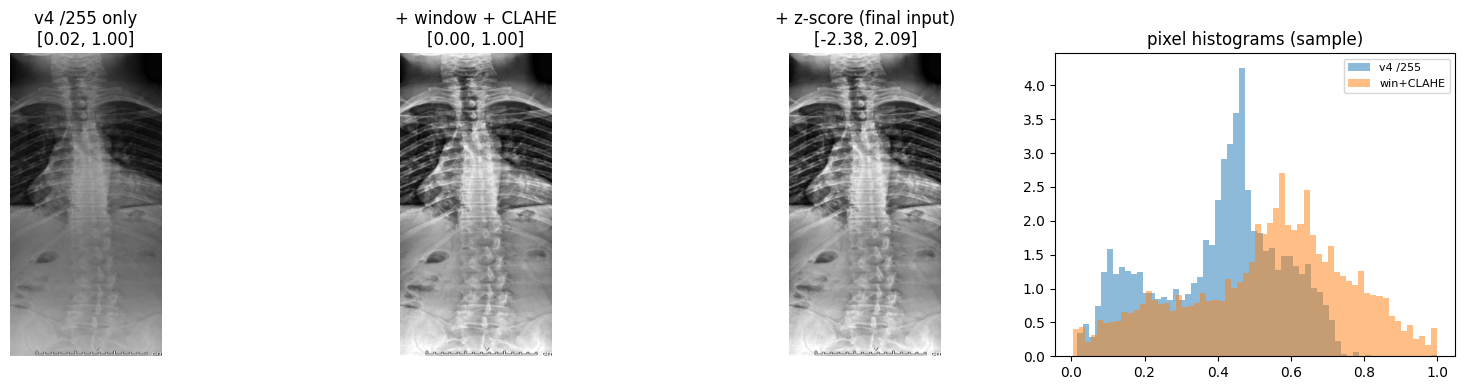

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(img_v4, cmap="gray")
axes[0].set_title(f"v4 /255 only\n[{img_v4.min():.2f}, {img_v4.max():.2f}]")
axes[1].imshow(img_clahe, cmap="gray")
axes[1].set_title(f"+ window + CLAHE\n[{img_clahe.min():.2f}, {img_clahe.max():.2f}]")
axes[2].imshow(img_z, cmap="gray")
axes[2].set_title(f"+ z-score (final input)\n[{img_z.min():.2f}, {img_z.max():.2f}]")
# pixel-value histogram comparison (single sample)
axes[3].hist(img_v4.ravel(), bins=60, alpha=0.5, label="v4 /255", density=True)
axes[3].hist(img_clahe.ravel(), bins=60, alpha=0.5, label="win+CLAHE", density=True)
axes[3].set_title("pixel histograms (sample)")
axes[3].legend(fontsize=8)
for ax in axes[:3]:
    ax.set_axis_off()
plt.tight_layout(); plt.show()


**Calibration: pixel-distribution stats across the dataset (TRAINABLE subsample).** Confirms the `[0.5, 99.5]` percentile window does not over-clip on this dataset's exposure variation. If the windowed-pre-CLAHE distribution looks reasonable across `n=32` random cases, the Tier-A pipeline is calibrated for our data and a single training run is justified before any tuning of `WINDOW_LO_PCT` / `WINDOW_HI_PCT`.


calibration on n=32 TRAINABLE samples
       raw_mean  raw_std  win_lo   win_hi  win_range  pct_lo  pct_hi  \
count    32.000   32.000  32.000   32.000     32.000  32.000  32.000   
mean     98.684   53.769  11.188  207.656    196.469   0.003   0.004   
std      17.888   13.305  12.119   29.548     30.925   0.002   0.001   
min      70.484   34.896   0.000  152.000    138.000   0.000   0.000   
25%      86.221   43.067   3.250  185.500    171.250   0.001   0.004   
50%      98.570   50.193   8.000  203.000    201.000   0.003   0.004   
75%     105.393   62.972  16.000  228.000    217.250   0.004   0.005   
max     138.557   78.744  58.000  255.000    251.000   0.005   0.005   

       clahe_mean  clahe_std  
count      32.000     32.000  
mean      120.328     66.237  
std        14.808      6.814  
min        97.794     56.508  
25%       108.329     61.087  
50%       117.857     64.549  
75%       132.744     71.556  
max       153.191     83.840  


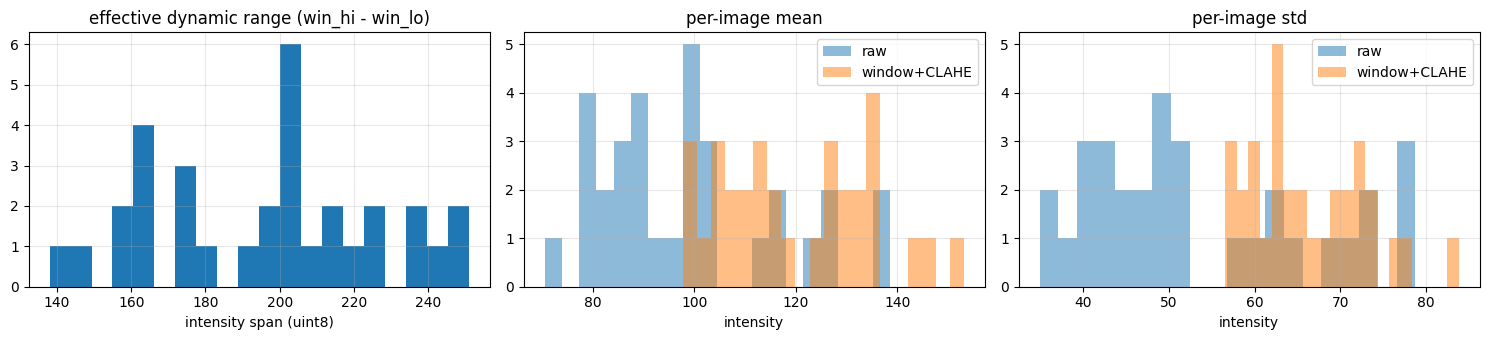

In [9]:
rng = np.random.default_rng(SEED)
calib_idx = rng.choice(len(TRAINABLE), size=min(32, len(TRAINABLE)), replace=False)
stats_rows = []
for i in calib_idx:
    row = TRAINABLE.iloc[i]
    raw_u8 = resize_image(read_gray(Path(row["image_path"])), IMG_H, IMG_W)
    raw_lo, raw_hi = np.percentile(raw_u8, [WINDOW_LO_PCT, WINDOW_HI_PCT])
    pct_clipped_lo = float((raw_u8 < raw_lo).mean())
    pct_clipped_hi = float((raw_u8 > raw_hi).mean())
    win_u8 = percentile_window_uint8(raw_u8)
    cl_u8 = real_clahe_uint8(win_u8)
    stats_rows.append({
        "raw_mean":  float(raw_u8.mean()),
        "raw_std":   float(raw_u8.std()),
        "win_lo":    float(raw_lo),
        "win_hi":    float(raw_hi),
        "win_range": float(raw_hi - raw_lo),
        "pct_lo":    pct_clipped_lo,
        "pct_hi":    pct_clipped_hi,
        "clahe_mean": float(cl_u8.mean()),
        "clahe_std":  float(cl_u8.std()),
    })
calib_df = pd.DataFrame(stats_rows)
print(f"calibration on n={len(calib_df)} TRAINABLE samples")
print(calib_df.describe().round(3))
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
axes[0].hist(calib_df["win_range"], bins=20)
axes[0].set(title="effective dynamic range (win_hi - win_lo)", xlabel="intensity span (uint8)")
axes[1].hist(calib_df["raw_mean"], bins=20, alpha=0.5, label="raw")
axes[1].hist(calib_df["clahe_mean"], bins=20, alpha=0.5, label="window+CLAHE")
axes[1].legend(); axes[1].set(title="per-image mean", xlabel="intensity")
axes[2].hist(calib_df["raw_std"], bins=20, alpha=0.5, label="raw")
axes[2].hist(calib_df["clahe_std"], bins=20, alpha=0.5, label="window+CLAHE")
axes[2].legend(); axes[2].set(title="per-image std", xlabel="intensity")
for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 2 · Cobb-Preserving Augmentation (lifted from v4)

Identical to v4. Operates on `[0, 1]` image **before** z-score, so the existing chain (`affine_transform`, `intensity_jitter`, `gamma_correction`, `clahe_like`, `gaussian_noise`, etc.) remains compatible without modification. The fake `clahe_like` augmentation is preserved — it now operates on already-CLAHE'd input and serves as a contrast-jitter regularizer.


In [10]:
def augment_v5_cobb_aware(image, seg):
    """Same chain as augment_v4 but returns a `cobb_preserved` flag that is
    False when elastic_deform fires (which can change the spinal curve).
    Horizontal flip preserves |Cobb|, so it does NOT mask the Cobb target."""
    cobb_preserved = True
    if torch.rand(1).item() < 0.7:
        image, seg = affine_transform(
            image, seg,
            angle_range=(-15.0, 15.0),
            translate_frac=0.10,
            scale_range=(0.85, 1.15),
        )
    if torch.rand(1).item() < 0.5:
        image, seg = horizontal_flip(image, seg)
    if torch.rand(1).item() < 0.4:
        image, seg = elastic_deform(image, seg, alpha=40.0, sigma=6.0)
        cobb_preserved = False
    if torch.rand(1).item() < 0.5:
        image = intensity_jitter(image, gain_range=(0.7, 1.3), bias_range=(-0.15, 0.15))
    if torch.rand(1).item() < 0.3:
        image = gamma_correction(image)
    if torch.rand(1).item() < 0.3:
        image = gaussian_blur(image)
    if torch.rand(1).item() < 0.2:
        image = clahe_like(image)
    if torch.rand(1).item() < 0.3:
        image = gaussian_noise(image, std_range=(0.0, 0.08))
    if torch.rand(1).item() < 0.25:
        image = coarse_dropout(image, n_patches=12, patch_size=40)
    return image, seg, cobb_preserved


## 3 · Multi-Task Dataset (Tier-A)

Same logic as v4's `MultiTaskSpineDataset`, with two changes:
- Reads via `preprocess_case_tierA(row, apply_zscore_now=False)` → `[0, 1]` image
- Applies `apply_zscore` to the (possibly augmented) image before returning, so the model sees `mean≈0, std≈1` input


In [11]:
class MultiTaskSpineDatasetTierA(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        augment: bool = False,
        target_ids: tuple[int, ...] = TARGET_IDS_V2,
    ):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.target_ids = target_ids

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, i: int) -> dict[str, torch.Tensor]:
        row = self.df.iloc[i]
        case = preprocess_case_tierA(row, target_ids=self.target_ids, apply_zscore_now=False)
        image, seg = case["image"], case["seg"]

        cobb_preserved = True
        if self.augment:
            image, seg, cobb_preserved = augment_v5_cobb_aware(image, seg)

        # z-score AFTER augment so existing aug chain (which assumes [0,1] input) keeps working
        image = apply_zscore(image)

        # re-extract keypoints from (possibly augmented) seg so they spatially agree
        seg_np = seg.numpy().astype(np.uint8)
        raw = np.zeros_like(seg_np)
        for k_idx, raw_id in enumerate(self.target_ids, start=1):
            raw[seg_np == k_idx] = raw_id
        kps_full = multiclass_mask_to_keypoints(raw, target_ids=self.target_ids)
        hm, valid = render_heatmaps(kps_full)

        cobb_val = row.get("cobb_angle_deg")
        has_gt = pd.notna(cobb_val) and cobb_preserved
        cobb_t = torch.tensor(float(cobb_val) if has_gt else 0.0, dtype=torch.float32)
        cobb_valid = torch.tensor(bool(has_gt))

        return {
            "image": image,
            "seg": seg,
            "kpt_heatmap": torch.from_numpy(hm),
            "kpt_valid": torch.from_numpy(valid),
            "cobb": cobb_t,
            "cobb_valid": cobb_valid,
        }


def multitask_collate(batch: list[dict]) -> dict[str, torch.Tensor]:
    return {k: torch.stack([b[k] for b in batch]) for k in batch[0]}


# sanity check one batch
_ds = MultiTaskSpineDatasetTierA(TRAIN_DF.head(4), augment=False)
_b = multitask_collate([_ds[i] for i in range(4)])
for k, v in _b.items():
    print(f"  {k:14s}  {tuple(v.shape)}  {v.dtype}")
img_b = _b["image"]
print(f"\nbatch image stats: mean={img_b.mean():+.3f} std={img_b.std():.3f} "
      f"min={img_b.min():+.3f} max={img_b.max():+.3f}  (z-score targets: mean≈0 std≈1)")


  image           (4, 1, 512, 256)  torch.float32
  seg             (4, 512, 256)  torch.int64
  kpt_heatmap     (4, 68, 128, 64)  torch.float32
  kpt_valid       (4, 68)  torch.bool
  cobb            (4,)  torch.float32
  cobb_valid      (4,)  torch.bool

batch image stats: mean=-0.000 std=1.000 min=-2.128 max=+2.408  (z-score targets: mean≈0 std≈1)


## 4 · MultiTask Architecture (identical to v4)

ResNet-34 encoder with seg + keypoint + Cobb heads. `in_ch=1`. **No architectural change** — this experiment isolates the preprocessing variable. ImageNet stats remain unapplied (z-scored input is the alternative per [[Preprocessing_options]] §A.1; A.2 ImageNet match is queued as a follow-up Tier-A.v2 ablation if this run lifts the floor).


In [12]:
def _conv_block(in_ch: int, out_ch: int) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )


class _Up(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = _conv_block(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        dy = skip.shape[2] - x.shape[2]
        dx = skip.shape[3] - x.shape[3]
        if dy != 0 or dx != 0:
            x = F.pad(x, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        return self.conv(torch.cat([x, skip], dim=1))


class MultiTaskEncoderUNet(nn.Module):
    """Shared ResNet-34 encoder with seg + keypoint + Cobb heads."""

    def __init__(
        self,
        in_ch: int = 1,
        num_seg_classes: int = NUM_SEG_CLASSES,
        num_keypoints: int = TOTAL_KEYPOINTS,
        pretrained: bool = True,
        dropout: float = 0.2,
        cobb_norm: float = 90.0,
    ):
        super().__init__()
        self.cobb_norm = cobb_norm

        weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet34(weights=weights)

        original_conv1 = backbone.conv1
        self.conv1 = nn.Conv2d(in_ch, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained and in_ch == 1:
            self.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)
        elif pretrained and in_ch == 3:
            self.conv1.weight.data = original_conv1.weight.data

        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.up1 = _Up(512, 256, 256)
        self.up2 = _Up(256, 128, 128)
        self.up3 = _Up(128, 64, 64)   # produces (B, 64, H/4, W/4) — keypoint tap
        self.up4 = _Up(64, 64, 64)    # produces (B, 64, H/2, W/2)
        self.final_up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.drop = nn.Dropout2d(dropout)

        # heads
        self.seg_head = nn.Conv2d(64, num_seg_classes, 1)
        self.kpt_head = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_keypoints, 1),
        )
        self.cobb_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

        self._encoder_modules = [
            self.conv1, self.bn1, self.layer1, self.layer2, self.layer3, self.layer4,
        ]
        self._decoder_modules = [
            self.up1, self.up2, self.up3, self.up4, self.final_up, self.drop,
            self.seg_head, self.kpt_head, self.cobb_head,
        ]

    def forward(self, x: torch.Tensor) -> dict[str, torch.Tensor]:
        x0 = self.relu(self.bn1(self.conv1(x)))
        x_pool = self.maxpool(x0)
        s1 = self.layer1(x_pool)
        s2 = self.layer2(s1)
        s3 = self.layer3(s2)
        bridge = self.layer4(s3)  # (B, 512, H/32, W/32) — Cobb tap

        y = self.up1(bridge, s3)
        y = self.up2(y, s2)
        y_q = self.up3(y, s1)              # (B, 64, H/4, W/4) — kpt tap
        y = self.up4(y_q, x0)
        y_full = self.final_up(y)          # (B, 64, H, W)
        y_full = self.drop(y_full)

        seg_logits = self.seg_head(y_full)
        kpt_heatmaps = self.kpt_head(y_q)  # (B, 68, H/4, W/4)
        cobb_norm_pred = self.cobb_head(bridge).squeeze(-1)  # (B,)
        cobb_pred = cobb_norm_pred * self.cobb_norm  # rescale to degrees

        return {
            "seg": seg_logits,
            "kpt": kpt_heatmaps,
            "cobb": cobb_pred,
        }

    def encoder_params(self):
        for m in self._encoder_modules:
            yield from m.parameters()

    def decoder_params(self):
        for m in self._decoder_modules:
            yield from m.parameters()


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


model = MultiTaskEncoderUNet(pretrained=True, dropout=0.2).to(DEVICE)
n_enc = sum(p.numel() for p in model.encoder_params())
n_dec = sum(p.numel() for p in model.decoder_params())
print(f"MultiTaskEncoderUNet total params: {count_params(model):,}")
print(f"  encoder: {n_enc:,}  decoder+heads: {n_dec:,}")

MultiTaskEncoderUNet total params: 24,501,303
  encoder: 21,278,400  decoder+heads: 3,222,903


Dropped Escape call with ulEscapeCode : 0x03007703


## 5 · Forward-Pass Sanity Check


In [13]:
model.eval()
sample_case = preprocess_case_tierA(TRAINABLE.iloc[0], apply_zscore_now=True)
with torch.no_grad():
    out = model(sample_case["image"].unsqueeze(0).to(DEVICE))
for k, v in out.items():
    print(f"  {k:6s}  {tuple(v.shape)}  {v.dtype}")


  seg     (1, 18, 512, 256)  torch.float32
  kpt     (1, 68, 128, 64)  torch.float32
  cobb    (1,)  torch.float32


## 6 · Multi-Task Loss (identical to v4)

`MixedLoss` = clamped Kendall on `(seg, cobb)` + fixed `λ_kpt = 1.0`. Unchanged from v4.


In [14]:
COBB_NORM = 90.0
LAMBDA_KPT = 1.0
LOG_VAR_MIN = -1.5
LOG_VAR_MAX = 4.0


def kpt_loss_fn(pred: torch.Tensor, target: torch.Tensor, valid: torch.Tensor) -> torch.Tensor:
    """Masked MSE. valid: (B, K) bool; pred/target: (B, K, h, w)."""
    mask = valid.float().unsqueeze(-1).unsqueeze(-1)
    diff = (pred - target) ** 2 * mask
    denom = mask.sum() * pred.shape[-1] * pred.shape[-2] + 1e-6
    return diff.sum() / denom


def cobb_loss_fn(
    pred_deg: torch.Tensor,
    target_deg: torch.Tensor,
    valid: torch.Tensor,
    norm: float = COBB_NORM,
) -> torch.Tensor:
    if not bool(valid.any()):
        return pred_deg.sum() * 0.0
    p = pred_deg[valid] / norm
    t = target_deg[valid] / norm
    return F.smooth_l1_loss(p, t)


class ClampedKendallLoss(nn.Module):
    """Kendall '17 task uncertainty weighting with clamped log-variances.

    Verified offline + in v3: clamping `log_var ∈ [-1.5, 4.0]` prevents the
    σ-blowup that broke v2's naïve Kendall when small-magnitude losses were
    in play.
    """

    def __init__(
        self,
        task_names: tuple[str, ...] = ("seg", "cobb"),
        log_var_min: float = LOG_VAR_MIN,
        log_var_max: float = LOG_VAR_MAX,
    ):
        super().__init__()
        self.task_names = task_names
        self.log_var = nn.Parameter(torch.zeros(len(task_names)))
        self.log_var_min = log_var_min
        self.log_var_max = log_var_max

    def forward(self, raws: dict[str, torch.Tensor]) -> tuple[torch.Tensor, dict[str, float]]:
        clamped = self.log_var.clamp(self.log_var_min, self.log_var_max)
        total = 0.0
        parts: dict[str, float] = {}
        for i, name in enumerate(self.task_names):
            lv = clamped[i]
            li = raws[name]
            term = 0.5 * torch.exp(-lv) * li + 0.5 * lv
            total = total + term
            parts[f"raw_{name}"] = float(li.detach().cpu())
            parts[f"log_var_{name}"] = float(self.log_var[i].detach().cpu())
            parts[f"weight_{name}"] = float((0.5 * torch.exp(-lv)).detach().cpu())
        return total, parts


class MixedLoss(nn.Module):
    """v4 loss: clamped Kendall over (seg, cobb) PLUS fixed-weight kpt MSE.

    The kpt term is held at a fixed weight on purpose — v2 proved that letting
    Kendall amplify the heatmap loss flips Cobb correlation. Here we keep kpt
    in the supervision graph as a regularizer, not a Cobb estimator.
    """

    def __init__(self, kpt_weight: float = LAMBDA_KPT) -> None:
        super().__init__()
        self.kendall = ClampedKendallLoss(("seg", "cobb"))
        self.kpt_weight = kpt_weight

    def forward(
        self,
        raws: dict[str, torch.Tensor],
    ) -> tuple[torch.Tensor, dict[str, float]]:
        kendall_total, parts = self.kendall({"seg": raws["seg"], "cobb": raws["cobb"]})
        kpt_term = self.kpt_weight * raws["kpt"]
        total = kendall_total + kpt_term
        parts["raw_kpt"] = float(raws["kpt"].detach().cpu())
        parts["weight_kpt"] = self.kpt_weight
        parts["loss"] = float(total.detach().cpu())
        return total, parts


def raw_losses_for(out: dict, batch: dict, dev: torch.device) -> dict[str, torch.Tensor]:
    return {
        "seg": seg_loss_fn(out["seg"], batch["seg"].to(dev), NUM_SEG_CLASSES),
        "kpt": kpt_loss_fn(
            out["kpt"],
            batch["kpt_heatmap"].to(dev),
            batch["kpt_valid"].to(dev),
        ),
        "cobb": cobb_loss_fn(
            out["cobb"],
            batch["cobb"].to(dev),
            batch["cobb_valid"].to(dev),
        ),
    }


## 7 · Training Loop

Same recipe as v4 (encoder freeze warmup 10 ep, cosine LR, dual-checkpoint dice/cobb, patience 25). Cache root = `ai/models/checkpoints/multitask_v4_tierA/` — isolated from v4 so reruns of either notebook don't collide. `run_config()` includes a `preprocessing` field so the hash differs from v4.


In [15]:
import hashlib
import json
from datetime import datetime

CHECKPOINT_ROOT = REPO_ROOT / "ai" / "models" / "checkpoints" / "multitask_v4_tierA"
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

NUM_EPOCHS = 150
BATCH_SIZE = 4
LR_ENCODER = 1e-4
LR_DECODER = 1e-3
LR_LOGVAR = 1e-3
WEIGHT_DECAY = 2e-4
WARMUP_EPOCHS = 10
PATIENCE = 25
DROPOUT = 0.2


def run_config() -> dict:
    return {
        "dataset": "v2_corrected",
        "arch": "MultiTaskEncoderUNetV4",
        "encoder": "resnet34",
        "num_seg_classes": NUM_SEG_CLASSES,
        "num_keypoints": TOTAL_KEYPOINTS,
        "heatmap_h": HM_H,
        "heatmap_w": HM_W,
        "heatmap_sigma": HEATMAP_SIGMA,
        "loss": "mixed_clamped_kendall_seg_cobb_plus_fixed_kpt",
        "lambda_kpt": LAMBDA_KPT,
        "log_var_min": LOG_VAR_MIN,
        "log_var_max": LOG_VAR_MAX,
        "cobb_norm": COBB_NORM,
        "augment": "v5_cobb_aware",
        "preprocessing": "tierA_window_clahe_zscore",
        "window_lo_pct": WINDOW_LO_PCT,
        "window_hi_pct": WINDOW_HI_PCT,
        "clahe_clip_limit": CLAHE_CLIP_LIMIT,
        "clahe_tile_grid": list(CLAHE_TILE_GRID),
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr_encoder": LR_ENCODER,
        "lr_decoder": LR_DECODER,
        "lr_logvar": LR_LOGVAR,
        "weight_decay": WEIGHT_DECAY,
        "warmup_epochs": WARMUP_EPOCHS,
        "patience": PATIENCE,
        "dropout": DROPOUT,
        "seed": SEED,
        "trainable_count": int(len(TRAINABLE)),
        "val_frac": 0.2,
    }


def cfg_hash(cfg: dict) -> str:
    return hashlib.sha256(json.dumps(cfg, sort_keys=True, default=str).encode()).hexdigest()[:8]


def find_cached(cfg: dict) -> Path | None:
    h = cfg_hash(cfg)
    for p in sorted(CHECKPOINT_ROOT.glob(f"*_{h}")):
        if (p / "model.pt").exists():
            return p
    return None


def new_run_dir(cfg: dict) -> Path:
    stamp = datetime.now().strftime("%Y%m%dT%H%M")
    p = CHECKPOINT_ROOT / f"{stamp}_{cfg_hash(cfg)}"
    p.mkdir(parents=True, exist_ok=True)
    return p


In [16]:
def train_step(
    model: nn.Module,
    loss_module: nn.Module,
    batch: dict,
    optimizer: torch.optim.Optimizer,
) -> dict[str, float]:
    out = model(batch["image"].to(DEVICE))
    raws = raw_losses_for(out, batch, DEVICE)
    total, parts = loss_module(raws)
    optimizer.zero_grad()
    total.backward()
    optimizer.step()
    return parts


@torch.no_grad()
def validate(model: nn.Module, loss_module: nn.Module, loader: DataLoader) -> dict[str, float]:
    model.eval()
    accum = {
        "loss": 0.0,
        "raw_seg": 0.0, "raw_kpt": 0.0, "raw_cobb": 0.0,
        "weight_seg": 0.0, "weight_cobb": 0.0,
    }
    inter = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    card = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    cobb_abs_err: list[float] = []
    n_batches = 0
    for batch in loader:
        out = model(batch["image"].to(DEVICE))
        raws = raw_losses_for(out, batch, DEVICE)
        total, parts = loss_module(raws)
        accum["loss"] += float(total.detach().cpu())
        for k in ("raw_seg", "raw_kpt", "raw_cobb", "weight_seg", "weight_cobb"):
            accum[k] += parts[k]

        pred_mask = out["seg"].argmax(dim=1)
        seg_t = batch["seg"].to(DEVICE)
        for c in range(1, NUM_SEG_CLASSES):
            p, g = (pred_mask == c), (seg_t == c)
            inter[c - 1] += (p & g).sum()
            card[c - 1] += p.sum() + g.sum()

        valid = batch["cobb_valid"]
        if valid.any():
            cobb_pred = out["cobb"].cpu()[valid]
            cobb_true = batch["cobb"][valid]
            cobb_abs_err.extend((cobb_pred - cobb_true).abs().tolist())
        n_batches += 1

    dice_per_cls = (2.0 * inter) / card.clamp(min=1e-6)
    valid_cls = card > 0
    return {
        **{k: v / max(1, n_batches) for k, v in accum.items()},
        "dice": float(dice_per_cls[valid_cls].mean()) if valid_cls.any() else float("nan"),
        "cobb_mae_direct": float(np.mean(cobb_abs_err)) if cobb_abs_err else float("nan"),
    }


In [17]:
cfg = run_config()
_cached = find_cached(cfg)
loss_module = MixedLoss().to(DEVICE)

if _cached is not None:
    state = torch.load(_cached / "model.pt", map_location=DEVICE)
    history_df = pd.read_csv(_cached / "history.csv")
    metrics_cache = json.loads((_cached / "metrics.json").read_text())
    model = MultiTaskEncoderUNet(pretrained=False, dropout=DROPOUT).to(DEVICE)
    model.load_state_dict(state["model"])
    loss_module.load_state_dict(state["loss_module"])
    best_dice = float(metrics_cache["best_val_dice"])
    best_cobb_mae = float(metrics_cache.get("best_val_cobb_mae", float("nan")))
    print(
        f"reused cached run <- {_cached.relative_to(REPO_ROOT)}  "
        f"best_dice={best_dice:.3f}  best_cobb_mae={best_cobb_mae:.2f}°"
    )
else:
    model = MultiTaskEncoderUNet(pretrained=True, dropout=DROPOUT).to(DEVICE)
    print(f"MultiTaskEncoderUNet params: {count_params(model):,}  dropout={DROPOUT}")

    train_loader = DataLoader(
        MultiTaskSpineDatasetTierA(TRAIN_DF, augment=True),
        batch_size=BATCH_SIZE, shuffle=True, collate_fn=multitask_collate,
    )
    val_loader = DataLoader(
        MultiTaskSpineDatasetTierA(VAL_DF, augment=False),
        batch_size=BATCH_SIZE, shuffle=False, collate_fn=multitask_collate,
    )

    for p in model.encoder_params():
        p.requires_grad = False
    optimizer = torch.optim.Adam([
        {"params": model.decoder_params(), "lr": LR_DECODER, "weight_decay": WEIGHT_DECAY},
        {"params": loss_module.parameters(), "lr": LR_LOGVAR, "weight_decay": 0.0},
    ])
    scheduler = None

    history: list[dict[str, float]] = []
    best_dice = -1.0
    best_cobb_mae = float("inf")
    best_dice_state: dict | None = None
    best_cobb_state: dict | None = None
    best_dice_epoch = -1
    best_cobb_epoch = -1
    no_improve = 0  # tracked against dice for early stopping

    t_start = time.time()
    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()

        if epoch == WARMUP_EPOCHS + 1:
            for p in model.encoder_params():
                p.requires_grad = True
            optimizer = torch.optim.Adam([
                {"params": model.encoder_params(), "lr": LR_ENCODER, "weight_decay": WEIGHT_DECAY},
                {"params": model.decoder_params(), "lr": LR_DECODER, "weight_decay": WEIGHT_DECAY},
                {"params": loss_module.parameters(), "lr": LR_LOGVAR, "weight_decay": 0.0},
            ])
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS
            )
            print(f"  >>> encoder unfrozen at epoch {epoch}")

        model.train()
        train_acc = {"loss": 0.0, "raw_seg": 0.0, "raw_kpt": 0.0, "raw_cobb": 0.0}
        n_steps = 0
        for batch in train_loader:
            parts = train_step(model, loss_module, batch, optimizer)
            train_acc["loss"] += parts["loss"]
            for k in ("raw_seg", "raw_kpt", "raw_cobb"):
                train_acc[k] += parts[k]
            n_steps += 1
        train_acc = {k: v / max(1, n_steps) for k, v in train_acc.items()}

        val_stats = validate(model, loss_module, val_loader)
        if scheduler is not None:
            scheduler.step()

        n_groups = len(optimizer.param_groups)
        row = {
            "epoch":         epoch,
            "train_loss":    train_acc["loss"],
            "train_seg":     train_acc["raw_seg"],
            "train_kpt":     train_acc["raw_kpt"],
            "train_cobb":    train_acc["raw_cobb"],
            "val_loss":      val_stats["loss"],
            "val_seg":       val_stats["raw_seg"],
            "val_kpt":       val_stats["raw_kpt"],
            "val_cobb":      val_stats["raw_cobb"],
            "w_seg":         val_stats["weight_seg"],
            "w_cobb":        val_stats["weight_cobb"],
            "val_dice":      val_stats["dice"],
            "val_cobb_mae":  val_stats["cobb_mae_direct"],
            "lr_enc":        float(optimizer.param_groups[0]["lr"]) if n_groups > 2 else 0.0,
            "lr_dec":        float(optimizer.param_groups[-2]["lr"]) if n_groups >= 2 else float(optimizer.param_groups[0]["lr"]),
            "sec":           time.time() - t0,
        }
        history.append(row)

        improved_dice = val_stats["dice"] > best_dice
        improved_cobb = (
            not math.isnan(val_stats["cobb_mae_direct"])
            and val_stats["cobb_mae_direct"] < best_cobb_mae
        )
        if improved_dice:
            best_dice = val_stats["dice"]
            best_dice_state = {
                "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                "loss_module": {k: v.detach().cpu().clone() for k, v in loss_module.state_dict().items()},
            }
            best_dice_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1
        if improved_cobb:
            best_cobb_mae = val_stats["cobb_mae_direct"]
            best_cobb_state = {
                "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
                "loss_module": {k: v.detach().cpu().clone() for k, v in loss_module.state_dict().items()},
            }
            best_cobb_epoch = epoch

        flags = ""
        if improved_dice:
            flags += " *D"
        if improved_cobb:
            flags += " *C"
        print(
            f"ep {epoch:3d}/{NUM_EPOCHS}  "
            f"tr={row['train_loss']:6.3f} (s={row['train_seg']:.2f} k={row['train_kpt']:.3f} c={row['train_cobb']:.3f})  "
            f"val={row['val_loss']:6.3f}  dice={row['val_dice']:.3f}  cobb={row['val_cobb_mae']:5.1f}°  "
            f"w[s/c]={row['w_seg']:.2f}/{row['w_cobb']:.2f}  ({row['sec']:.1f}s){flags}"
        )

        if epoch > WARMUP_EPOCHS and no_improve >= PATIENCE:
            print(f"\n  >>> early stop at epoch {epoch}, no dice improvement for {PATIENCE} epochs")
            break

    # restore the best-dice state into the live model (eval cells consume it)
    if best_dice_state is not None:
        model.load_state_dict(best_dice_state["model"])
        loss_module.load_state_dict(best_dice_state["loss_module"])
    history_df = pd.DataFrame(history)

    run_dir = new_run_dir(cfg)
    if best_dice_state is not None:
        torch.save(best_dice_state, run_dir / "model.pt")  # primary ckpt = best dice
    if best_cobb_state is not None:
        torch.save(best_cobb_state, run_dir / "model_best_cobb.pt")
    history_df.to_csv(run_dir / "history.csv", index=False)
    (run_dir / "config.json").write_text(json.dumps(cfg, indent=2, default=str))
    (run_dir / "metrics.json").write_text(json.dumps({
        "best_val_dice": best_dice,
        "best_val_dice_epoch": best_dice_epoch,
        "best_val_cobb_mae": best_cobb_mae if best_cobb_mae != float("inf") else None,
        "best_val_cobb_mae_epoch": best_cobb_epoch,
        "stopped_epoch": int(history_df["epoch"].iloc[-1]),
        "final_log_var": loss_module.kendall.log_var.detach().cpu().tolist(),
    }, indent=2))
    print(
        f"\ntotal time: {time.time() - t_start:.1f}s  "
        f"best dice={best_dice:.3f}@ep{best_dice_epoch}  "
        f"best cobb_mae={best_cobb_mae:.2f}°@ep{best_cobb_epoch}"
    )
    print(f"saved -> {run_dir.relative_to(REPO_ROOT)}")


MultiTaskEncoderUNet params: 24,501,303  dropout=0.2
ep   1/150  tr= 0.729 (s=1.41 k=0.016 c=0.045)  val= 0.662  dice=0.018  cobb= 18.6°  w[s/c]=0.48/0.53  (13.6s) *D *C
ep   2/150  tr= 0.615 (s=1.26 k=0.002 c=0.050)  val= 0.585  dice=0.025  cobb= 19.4°  w[s/c]=0.46/0.55  (15.9s) *D
ep   3/150  tr= 0.543 (s=1.19 k=0.002 c=0.027)  val= 0.501  dice=0.093  cobb= 19.0°  w[s/c]=0.46/0.58  (12.9s) *D
ep   4/150  tr= 0.481 (s=1.10 k=0.002 c=0.032)  val= 0.509  dice=0.084  cobb= 22.5°  w[s/c]=0.45/0.61  (12.6s)
ep   5/150  tr= 0.441 (s=1.07 k=0.002 c=0.029)  val= 0.420  dice=0.143  cobb= 17.3°  w[s/c]=0.46/0.64  (15.7s) *D *C
ep   6/150  tr= 0.398 (s=1.02 k=0.002 c=0.033)  val= 0.344  dice=0.253  cobb= 17.6°  w[s/c]=0.46/0.68  (12.9s) *D
ep   7/150  tr= 0.351 (s=0.99 k=0.002 c=0.025)  val= 0.326  dice=0.278  cobb= 23.0°  w[s/c]=0.47/0.71  (15.4s) *D
ep   8/150  tr= 0.324 (s=0.98 k=0.001 c=0.026)  val= 0.380  dice=0.147  cobb= 20.2°  w[s/c]=0.48/0.75  (12.9s)
ep   9/150  tr= 0.291 (s=0.96 k=0.0

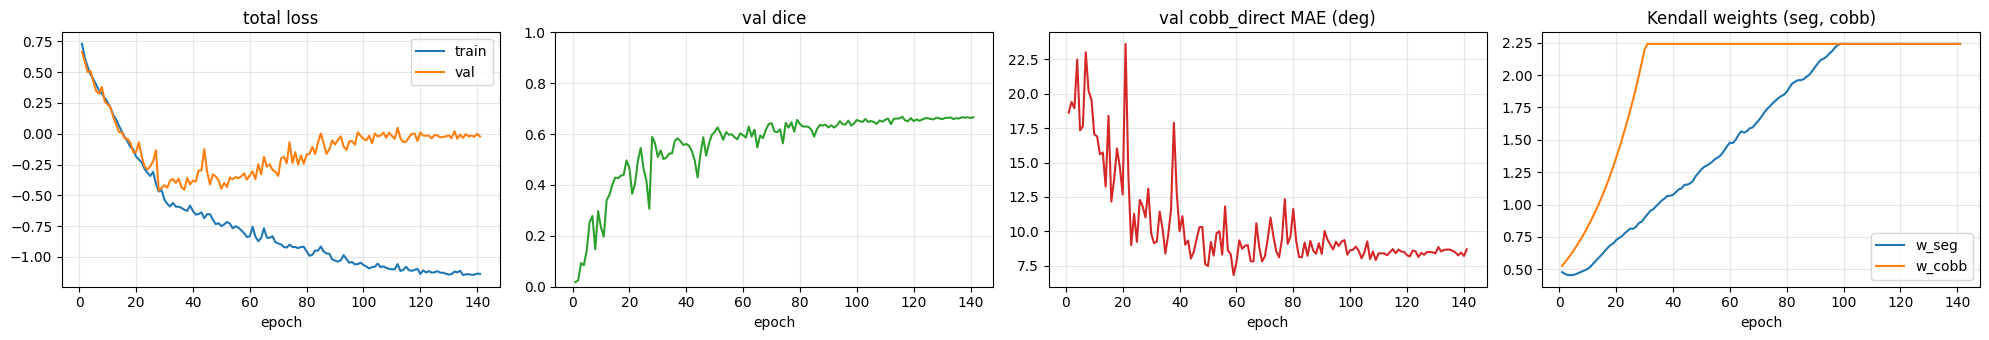

In [18]:
fig, axes = plt.subplots(1, 4, figsize=(20, 3.5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"],   label="val")
axes[0].set(title="total loss", xlabel="epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["val_dice"], color="tab:green")
axes[1].set(title="val dice", xlabel="epoch", ylim=(0.0, 1.0))
axes[1].grid(alpha=0.3)

axes[2].plot(history_df["epoch"], history_df["val_cobb_mae"], color="tab:red")
axes[2].set(title="val cobb_direct MAE (deg)", xlabel="epoch")
axes[2].grid(alpha=0.3)

axes[3].plot(history_df["epoch"], history_df["w_seg"],  label="w_seg")
axes[3].plot(history_df["epoch"], history_df["w_cobb"], label="w_cobb")
axes[3].set(title="Kendall weights (seg, cobb)", xlabel="epoch")
axes[3].legend(); axes[3].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 8 · Evaluation — Three Cobb Estimators (Tier-A inputs)

Same three independent paths as v4: cobb_head direct, kpt-heatmaps, seg-derived tangent. `evaluate_case` rewrites to call `preprocess_case_tierA(row, apply_zscore_now=True)` so the model sees the same input distribution it was trained on.


In [19]:
def cobb_from_keypoints(coords_xy: np.ndarray, num_vert: int = NUM_VERT) -> float:
    """Brute-force pairwise endplate angle.

    coords_xy: (68, 2) float, NaN where keypoint missing. Order: TL, TR, BL, BR per vertebra.
    Returns max absolute difference (deg) between any two endplate slopes.
    """
    angles_top = []
    angles_bot = []
    indices = []
    for v in range(num_vert):
        tl, tr, bl, br = coords_xy[4 * v : 4 * v + 4]
        if np.isfinite(tl).all() and np.isfinite(tr).all():
            dy = tr[1] - tl[1]
            dx = tr[0] - tl[0]
            angles_top.append(math.degrees(math.atan2(dy, dx)))
        else:
            angles_top.append(np.nan)
        if np.isfinite(bl).all() and np.isfinite(br).all():
            dy = br[1] - bl[1]
            dx = br[0] - bl[0]
            angles_bot.append(math.degrees(math.atan2(dy, dx)))
        else:
            angles_bot.append(np.nan)
        indices.append(v)
    a = np.array(angles_top + angles_bot)
    a = a[np.isfinite(a)]
    if len(a) < 2:
        return float("nan")
    diffs = np.abs(a[:, None] - a[None, :])
    return float(diffs.max())


@torch.no_grad()
def evaluate_case(model: nn.Module, row: pd.Series) -> dict:
    case = preprocess_case_tierA(row, apply_zscore_now=True)
    out = model(case["image"].unsqueeze(0).to(DEVICE))
    seg_pred = out["seg"].argmax(dim=1).squeeze(0).cpu()
    kpt_hm = out["kpt"].squeeze(0).cpu()
    cobb_direct = float(out["cobb"].squeeze(0).cpu())

    # dice (mean over present target classes)
    dice_scores: list[float] = []
    for c in range(1, NUM_SEG_CLASSES):
        p, g = (seg_pred == c), (case["seg"] == c)
        denom = p.sum() + g.sum()
        if denom > 0:
            dice_scores.append(float(2.0 * (p & g).sum() / denom))
    dice_mean = float(np.mean(dice_scores)) if dice_scores else float("nan")

    # Cobb from seg pipeline (existing)
    cobb_from_seg = float(cobb_from_segmentation_tangent(seg_pred.numpy()))
    # Cobb from keypoint heatmaps
    coords, _scores = keypoints_from_heatmaps(kpt_hm)
    cobb_from_kpt = cobb_from_keypoints(coords)

    out_row = {
        "dice": dice_mean,
        "cobb_direct": cobb_direct,
        "cobb_from_seg": cobb_from_seg,
        "cobb_from_kpt": cobb_from_kpt,
    }
    gt = row.get("cobb_angle_deg")
    if pd.notna(gt):
        gt = float(gt)
        out_row["cobb_true"] = gt
        for k in ["cobb_direct", "cobb_from_seg", "cobb_from_kpt"]:
            v = out_row[k]
            out_row[f"{k}_abs_err"] = abs(v - gt) if np.isfinite(v) else float("nan")
    return out_row

eval_rows = [evaluate_case(model, r) for _, r in VAL_DF.iterrows()]
eval_df = pd.DataFrame(eval_rows)
print(f"evaluated {len(eval_df)} val cases")
eval_df.head()

evaluated 50 val cases


,dice,cobb_direct,cobb_from_seg,cobb_from_kpt,cobb_true,cobb_direct_abs_err,cobb_from_seg_abs_err,cobb_from_kpt_abs_err
0,0.544576,83.752151,73.855404,59.215853,80.171357,3.580794,6.315953,20.955504
1,0.946312,48.659428,12.930231,18.019769,NaN,NaN,NaN,NaN
2,0.355997,93.700859,121.560883,52.125016,90.000000,3.700859,31.560883,37.874984
3,0.885858,37.507320,9.731574,64.653824,NaN,NaN,NaN,NaN
4,0.882309,37.507320,40.000182,59.981633,37.935438,0.428118,2.064744,22.046195


In [20]:
summary = {
    "n_val":             int(len(eval_df)),
    "mean_dice":         float(eval_df["dice"].mean()),
}
with_gt = eval_df.dropna(subset=["cobb_true"]) if "cobb_true" in eval_df else pd.DataFrame()
if len(with_gt):
    summary["n_with_cobb_gt"] = int(len(with_gt))
    for col in ["cobb_direct", "cobb_from_seg", "cobb_from_kpt"]:
        err = with_gt[f"{col}_abs_err"].dropna()
        if len(err):
            summary[f"{col}_mae"] = float(err.mean())
            summary[f"{col}_n"] = int(len(err))

print("=== Multi-Task v4 + Tier-A preprocessing — single 80/20 split ===")
for k, v in summary.items():
    print(f"  {k:30s} {v}")
print()
print("Leaderboard reference (single 80/20):")
print(f"  v4 Kendall (baseline)       dice 0.680   cobb_direct MAE 5.79°  @ ep 54")
print(f"  v4 fixed-weight control     dice 0.683   cobb_direct MAE 6.69°  @ ep 54")
print()
print("Tier-A acceptance gate (preprocessing-only ablation):")
print(f"  no-regression: dice >= 0.680")
print(f"  win:           cobb_direct MAE <= 5.79° -> preprocessing was the gap, stack Q-18")
print(f"  modest help:   5.79 < cobb < 6.69       -> proceed to Q-18 anyway")
print(f"  no help:       cobb >= 6.69             -> ablate which of (window/CLAHE/zscore) hurt")

=== Multi-Task v4 + Tier-A preprocessing — single 80/20 split ===
  n_val                          50
  mean_dice                      0.6768239303779623
  n_with_cobb_gt                 32
  cobb_direct_mae                8.408537782265586
  cobb_direct_n                  32
  cobb_from_seg_mae              13.517700475026675
  cobb_from_seg_n                32
  cobb_from_kpt_mae              15.687944971983013
  cobb_from_kpt_n                32

Leaderboard reference (single 80/20):
  v4 Kendall (baseline)       dice 0.680   cobb_direct MAE 5.79°  @ ep 54
  v4 fixed-weight control     dice 0.683   cobb_direct MAE 6.69°  @ ep 54

Tier-A acceptance gate (preprocessing-only ablation):
  no-regression: dice >= 0.680
  win:           cobb_direct MAE <= 5.79° -> preprocessing was the gap, stack Q-18
  modest help:   5.79 < cobb < 6.69       -> proceed to Q-18 anyway
  no help:       cobb >= 6.69             -> ablate which of (window/CLAHE/zscore) hurt


## 9 · Qualitative Check


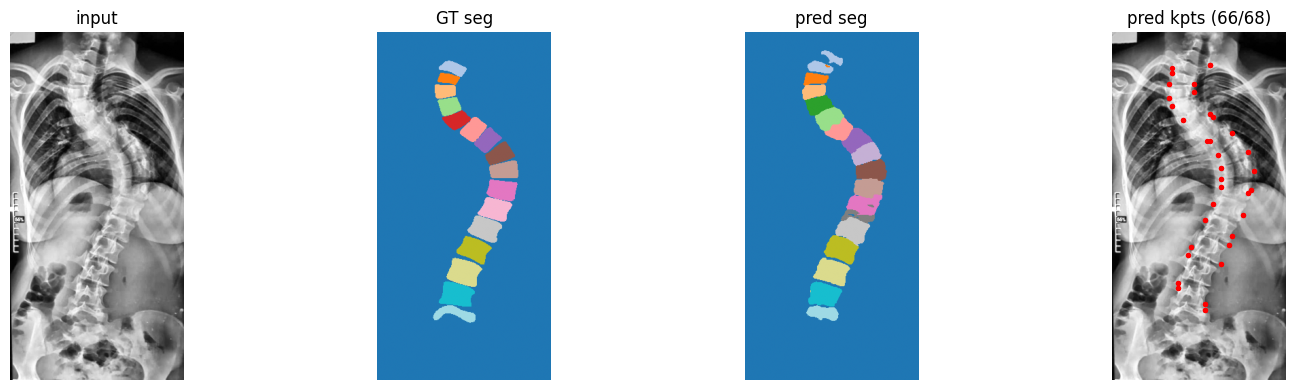

In [21]:
row = VAL_DF.iloc[0]
case = preprocess_case_tierA(row, apply_zscore_now=True)
model.eval()
with torch.no_grad():
    out = model(case["image"].unsqueeze(0).to(DEVICE))
seg_pred = out["seg"].argmax(dim=1).squeeze(0).cpu()
kpt_hm = out["kpt"].squeeze(0).cpu()
coords, scores = keypoints_from_heatmaps(kpt_hm)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("input")
axes[1].imshow(case["seg"], cmap="tab20"); axes[1].set_title("GT seg")
axes[2].imshow(seg_pred, cmap="tab20"); axes[2].set_title("pred seg")
axes[3].imshow(case["image"].squeeze(0), cmap="gray")
fin = np.isfinite(coords).all(axis=1)
axes[3].scatter(coords[fin, 0], coords[fin, 1], s=8, c="red")
axes[3].set_title(f"pred kpts ({int(fin.sum())}/68)")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 10 · Conclusions

TODO after the run: fill in mean dice / cobb_direct MAE / r / sev_acc and the per-cell deltas vs the v4 baseline row in [[hot.md]] §Leaderboard.

Decision tree per [[hot.md]] §Active Threads:
- **Δcobb ≥ 1.0°** → preprocessing was dominant gap → stack Q-18 corner-chaining on top, then Q-01 5-fold CV on the winning combo.
- **0.0° ≤ Δcobb < 1.0°** → modest help → run Q-18 anyway; decide Q-01 timing on whether stack reaches ~5°.
- **Δcobb < 0.0°** → ablate which of (window / CLAHE / z-score) hurt; file as [[experiments]] negative result with explanation; pivot to Q-18.

If this run wins, also queue a Tier-A.v2 ablation that tests adding ImageNet stats (3-channel duplicate input + per-channel mean/std) per [[Preprocessing_options]] §A.2.
